In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Sample - Superstore.csv", encoding="cp1252")

In [3]:
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [4]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
#------DATA CLEANING-------

In [7]:
#check null values
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [8]:
#convert data types
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Ship Date']=pd.to_datetime(df['Ship Date'])

In [9]:
#check duplicates
print(df.duplicated().sum())
duplicates = df[df.duplicated()]
print(duplicates)

0
Empty DataFrame
Columns: [Row ID, Order ID, Order Date, Ship Date, Ship Mode, Customer ID, Customer Name, Segment, Country, City, State, Postal Code, Region, Product ID, Category, Sub-Category, Product Name, Sales, Quantity, Discount, Profit]
Index: []

[0 rows x 21 columns]


In [10]:
#-----EDA-------
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()
print(daily_sales.head())

  Order Date     Sales
0 2014-01-03    16.448
1 2014-01-04   288.060
2 2014-01-05    19.536
3 2014-01-06  4407.100
4 2014-01-07    87.158


In [11]:
import matplotlib.pyplot as plt

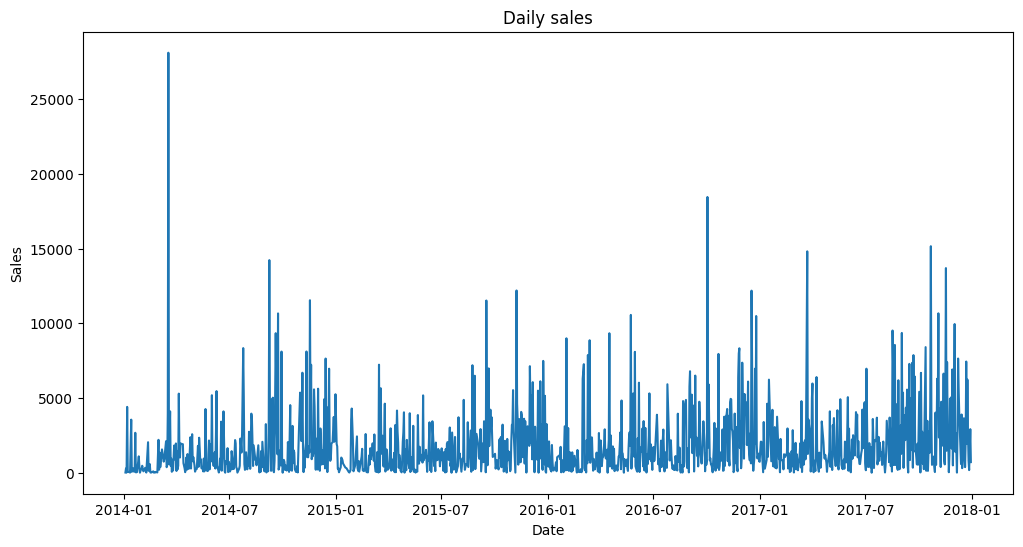

In [42]:
plt.figure(figsize=(12,6))
plt.plot(daily_sales['Order Date'],daily_sales['Sales'])
plt.title('Daily sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.savefig("daily_sales.png", dpi=300, bbox_inches='tight')
plt.show()

In [13]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
print(monthly_sales.head())

  Order Date      Sales
0    2014-01  14236.895
1    2014-02   4519.892
2    2014-03  55691.009
3    2014-04  28295.345
4    2014-05  23648.287


period[M] float64


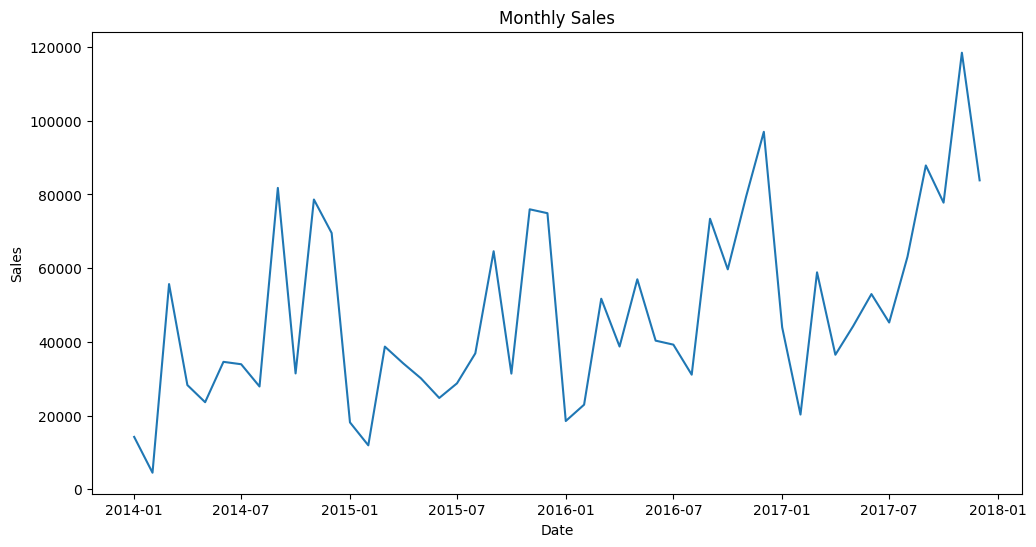

In [48]:
print(monthly_sales['Order Date'].dtype,monthly_sales['Sales'].dtype)
plt.figure(figsize=(12,6))
plt.plot(monthly_sales['Order Date'].dt.to_timestamp(),monthly_sales['Sales'])
plt.title('Monthly Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.savefig("monthly_sales.png", dpi=300, bbox_inches='tight')
plt.show()

In [15]:
category_sales = df.groupby('Category')['Sales'].sum()
print(category_sales.head())

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


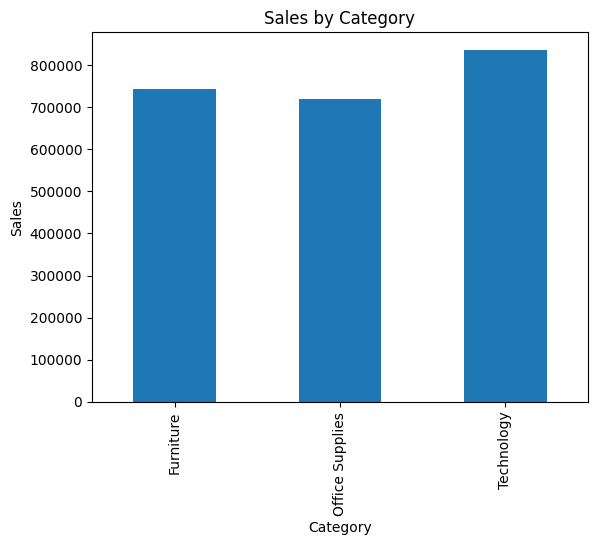

In [49]:
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.savefig("sales_by_category.png", dpi=300, bbox_inches='tight')
plt.show()

In [17]:
#------TIME BASED FEATURE ENGINEERING--------

In [18]:
#Date based features
print(daily_sales.head())

  Order Date     Sales
0 2014-01-03    16.448
1 2014-01-04   288.060
2 2014-01-05    19.536
3 2014-01-06  4407.100
4 2014-01-07    87.158


In [19]:
daily_sales['Year']=daily_sales['Order Date'].dt.year
daily_sales['Month']=daily_sales['Order Date'].dt.month
daily_sales['Day']=daily_sales['Order Date'].dt.day
daily_sales['Day of week']=daily_sales['Order Date'].dt.dayofweek
daily_sales['Quarter']=daily_sales['Order Date'].dt.quarter

print(daily_sales.head())

  Order Date     Sales  Year  Month  Day  Day of week  Quarter
0 2014-01-03    16.448  2014      1    3            4        1
1 2014-01-04   288.060  2014      1    4            5        1
2 2014-01-05    19.536  2014      1    5            6        1
3 2014-01-06  4407.100  2014      1    6            0        1
4 2014-01-07    87.158  2014      1    7            1        1


In [20]:
#trend based features
daily_sales['Time_Index'] = range(len(daily_sales))
daily_sales['Avg of week'] = daily_sales['Sales'].rolling(7).mean()
daily_sales['Avg of week']=daily_sales['Avg of week'].fillna(0)
daily_sales['Lag_1'] = daily_sales['Sales'].shift(1)
daily_sales['Lag_1']=daily_sales['Lag_1'].fillna(0)
daily_sales['Lag_7'] = daily_sales['Sales'].shift(7)
daily_sales['Lag_7']=daily_sales['Lag_7'].fillna(0)
print(daily_sales.head(10))

  Order Date     Sales  Year  Month  Day  Day of week  Quarter  Time_Index  \
0 2014-01-03    16.448  2014      1    3            4        1           0   
1 2014-01-04   288.060  2014      1    4            5        1           1   
2 2014-01-05    19.536  2014      1    5            6        1           2   
3 2014-01-06  4407.100  2014      1    6            0        1           3   
4 2014-01-07    87.158  2014      1    7            1        1           4   
5 2014-01-09    40.544  2014      1    9            3        1           5   
6 2014-01-10    54.830  2014      1   10            4        1           6   
7 2014-01-11     9.940  2014      1   11            5        1           7   
8 2014-01-13  3553.795  2014      1   13            0        1           8   
9 2014-01-14    61.960  2014      1   14            1        1           9   

   Avg of week     Lag_1    Lag_7  
0     0.000000     0.000    0.000  
1     0.000000    16.448    0.000  
2     0.000000   288.060    0.000

In [21]:
monthly_sales['Year'] = monthly_sales['Order Date'].dt.year
monthly_sales['Month_Num'] = monthly_sales['Order Date'].dt.month
monthly_sales['Quarter'] = monthly_sales['Order Date'].dt.quarter
monthly_sales['Quarter'] = monthly_sales['Order Date'].dt.quarter
print(monthly_sales.head())

  Order Date      Sales  Year  Month_Num  Quarter
0    2014-01  14236.895  2014          1        1
1    2014-02   4519.892  2014          2        1
2    2014-03  55691.009  2014          3        1
3    2014-04  28295.345  2014          4        2
4    2014-05  23648.287  2014          5        2


In [22]:
def get_season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Summer'
    elif month in [6,7,8]:
        return 'Spring'
    else:
        return 'Rainy'

In [23]:
monthly_sales['Season']=monthly_sales['Month_Num'].apply(get_season)

print(monthly_sales.head())

  Order Date      Sales  Year  Month_Num  Quarter  Season
0    2014-01  14236.895  2014          1        1  Winter
1    2014-02   4519.892  2014          2        1  Winter
2    2014-03  55691.009  2014          3        1  Summer
3    2014-04  28295.345  2014          4        2  Summer
4    2014-05  23648.287  2014          5        2  Summer


In [24]:
#Add features in daily sales
season_df=monthly_sales[['Month_Num','Season']].drop_duplicates()
print(season_df)

    Month_Num  Season
0           1  Winter
1           2  Winter
2           3  Summer
3           4  Summer
4           5  Summer
5           6  Spring
6           7  Spring
7           8  Spring
8           9   Rainy
9          10   Rainy
10         11   Rainy
11         12  Winter


In [25]:
daily_sales=daily_sales.merge(
    season_df,
    left_on='Month',
    right_on='Month_Num',
    how='left')

daily_sales.drop(columns='Month_Num', inplace=True)

print(daily_sales.head(10))

  Order Date     Sales  Year  Month  Day  Day of week  Quarter  Time_Index  \
0 2014-01-03    16.448  2014      1    3            4        1           0   
1 2014-01-04   288.060  2014      1    4            5        1           1   
2 2014-01-05    19.536  2014      1    5            6        1           2   
3 2014-01-06  4407.100  2014      1    6            0        1           3   
4 2014-01-07    87.158  2014      1    7            1        1           4   
5 2014-01-09    40.544  2014      1    9            3        1           5   
6 2014-01-10    54.830  2014      1   10            4        1           6   
7 2014-01-11     9.940  2014      1   11            5        1           7   
8 2014-01-13  3553.795  2014      1   13            0        1           8   
9 2014-01-14    61.960  2014      1   14            1        1           9   

   Avg of week     Lag_1    Lag_7  Season  
0     0.000000     0.000    0.000  Winter  
1     0.000000    16.448    0.000  Winter  
2     0.0

In [26]:
daily_qty=(
    df.groupby('Order Date')['Quantity'].sum().reset_index()
)

daily_sales=daily_sales.merge(
    daily_qty,
    on='Order Date',
    how='left'
)

print(daily_sales.head(10))

  Order Date     Sales  Year  Month  Day  Day of week  Quarter  Time_Index  \
0 2014-01-03    16.448  2014      1    3            4        1           0   
1 2014-01-04   288.060  2014      1    4            5        1           1   
2 2014-01-05    19.536  2014      1    5            6        1           2   
3 2014-01-06  4407.100  2014      1    6            0        1           3   
4 2014-01-07    87.158  2014      1    7            1        1           4   
5 2014-01-09    40.544  2014      1    9            3        1           5   
6 2014-01-10    54.830  2014      1   10            4        1           6   
7 2014-01-11     9.940  2014      1   11            5        1           7   
8 2014-01-13  3553.795  2014      1   13            0        1           8   
9 2014-01-14    61.960  2014      1   14            1        1           9   

   Avg of week     Lag_1    Lag_7  Season  Quantity  
0     0.000000     0.000    0.000  Winter         2  
1     0.000000    16.448    0.000

In [27]:
daily_categ=(
    df.pivot_table(
        index='Order Date',
        columns='Category',
        values='Sales',
        aggfunc='sum',
        fill_value=0
    )
)
print(daily_categ)
daily_sales=daily_sales.merge(
    daily_categ,
    left_on='Order Date',
    right_on='Order Date',
    how='left')

print(daily_sales.head(10))

Category    Furniture  Office Supplies  Technology
Order Date                                        
2014-01-03     0.0000           16.448       0.000
2014-01-04     0.0000          288.060       0.000
2014-01-05     0.0000           19.536       0.000
2014-01-06  2573.8200          685.340    1147.940
2014-01-07    76.7280           10.430       0.000
...               ...              ...         ...
2017-12-26     0.0000          814.594       0.000
2017-12-27     0.0000           13.248     164.388
2017-12-28   551.2568         1091.244      14.850
2017-12-29  2330.7180          282.440     302.376
2017-12-30   323.1360          299.724      90.930

[1237 rows x 3 columns]
  Order Date     Sales  Year  Month  Day  Day of week  Quarter  Time_Index  \
0 2014-01-03    16.448  2014      1    3            4        1           0   
1 2014-01-04   288.060  2014      1    4            5        1           1   
2 2014-01-05    19.536  2014      1    5            6        1           2   


In [28]:
daily_region=(
    df.pivot_table(
        index='Order Date',
        columns='Region',
        values='Sales',
        aggfunc='sum',
        fill_value=0
    )
)

daily_sales=daily_sales.merge(
    daily_region,
    left_on='Order Date',
    right_on='Order Date',
    how='left'
)

print(daily_sales.head(10))

  Order Date     Sales  Year  Month  Day  Day of week  Quarter  Time_Index  \
0 2014-01-03    16.448  2014      1    3            4        1           0   
1 2014-01-04   288.060  2014      1    4            5        1           1   
2 2014-01-05    19.536  2014      1    5            6        1           2   
3 2014-01-06  4407.100  2014      1    6            0        1           3   
4 2014-01-07    87.158  2014      1    7            1        1           4   
5 2014-01-09    40.544  2014      1    9            3        1           5   
6 2014-01-10    54.830  2014      1   10            4        1           6   
7 2014-01-11     9.940  2014      1   11            5        1           7   
8 2014-01-13  3553.795  2014      1   13            0        1           8   
9 2014-01-14    61.960  2014      1   14            1        1           9   

   Avg of week     Lag_1    Lag_7  Season  Quantity  Furniture  \
0     0.000000     0.000    0.000  Winter         2      0.000   
1     0.0

In [30]:
daily_sales['Lag_14'] = daily_sales['Sales'].shift(14)
daily_sales['Lag_14']=daily_sales['Lag_14'].fillna(0)
daily_sales['Lag_30'] = daily_sales['Sales'].shift(30)
daily_sales['Lag_30']=daily_sales['Lag_30'].fillna(0)
daily_sales['Rolling_14'] = (
    daily_sales['Sales']
    .rolling(14)
    .mean()
)
daily_sales['Rolling_14']=daily_sales['Rolling_14'].fillna(0)

# Stronger lag features — mirror your dominant ones
daily_sales['Lag_7_rolling_mean']  = daily_sales['Sales'].shift(7).rolling(3).mean()
daily_sales['Lag_7_rolling_mean']=daily_sales['Lag_7_rolling_mean'] .fillna(0)
daily_sales['Lag_14_rolling_std']  = daily_sales['Sales'].shift(14).rolling(7).std()
daily_sales['Lag_14_rolling_std']=daily_sales['Lag_14_rolling_std'] .fillna(0)

# Interaction between your top features
daily_sales['Qty_x_AvgWeek'] = daily_sales['Quantity'] * daily_sales['Avg of week']

# Cyclic encoding — better than raw Day/Month integers
import numpy as np
daily_sales['month_sin'] = np.sin(2 * np.pi * daily_sales['Month'] / 12)
daily_sales['month_cos'] = np.cos(2 * np.pi * daily_sales['Month'] / 12)
daily_sales['dow_sin']   = np.sin(2 * np.pi * daily_sales['Day of week'] / 7)
daily_sales['dow_cos']   = np.cos(2 * np.pi * daily_sales['Day of week'] / 7)
# Expanding mean (historical average up to that point)
daily_sales['expanding_mean'] = daily_sales['Sales'].shift(1).expanding().mean()
daily_sales['expanding_mean']=daily_sales['expanding_mean'].fillna(0)

In [31]:
#pip install openpyxl

In [32]:
daily_sales.to_csv("Processed_Sales_data.csv", index=False)
daily_sales.to_excel("Processed_Sales_data.xlsx", index=False)

In [33]:
import os

print(os.path.abspath("Processed_Sales_data.csv"))

C:\Users\A J OVIYAA\Processed_Sales_data.csv


Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
dtype: float64


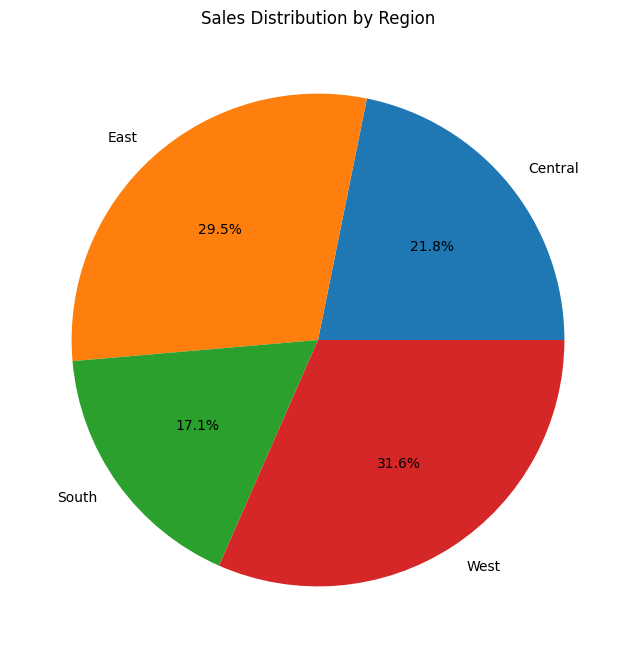

In [50]:
region_totals = daily_region.sum()
print(region_totals)
plt.figure(figsize=(8,8))

plt.pie(
    region_totals,
    labels=region_totals.index,
    autopct='%1.1f%%'
)

plt.title('Sales Distribution by Region')
plt.savefig("sales_by_region.png", dpi=300, bbox_inches='tight')
plt.show()